# Quasi-steady simulation of a test-bench log

This notebook takes a long time-series log from a test bench
(`monocell_datas_03Mar2026_08h10.csv`, MEA62) and, **without aggregating
into discrete operating points**, replays the logged setpoints through a
:class:`~marapendi.model.ExplicitSteadyStateModel`:

1. Load the log.
2. Build the same MEA62 cell as in `01_cell_assembly_and_polarization_curve.ipynb`.
3. For (almost) every logged sample, build a
   :class:`~marapendi.conditions.CellOperatingConditions` from the logged
   setpoints (current, cell temperature, pressures, relative humidities,
   stoichiometries) and evaluate the steady-state model.
4. Plot the simulated and measured main variables against time.

**Caveat.** The model is evaluated quasi-statically: each sample is treated
as an independent steady-state operating point, ignoring thermal and water
transients between samples. Periods where `I_Pile(A)` is (close to) zero
are excluded from the simulation because the steady-state model is not
well-defined at zero current (the channel flow rate, set from the
stoichiometry, becomes ill-defined). Over the range of currents present in
this log, the logged stack voltage `U_Pile(V)` is approximately
proportional to `I_Pile(A)` (a resistive-load-like relationship), which
suggests this log is a low-power conditioning sequence rather than a full
polarization sweep. The number of cells in the stack (`N_CELLS`) and the
active area (`CELL_AREA`) are not recorded in the log; they are exposed
below as parameters to adjust for the actual test rig.

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from marapendi.electrochemistry import ElectrochemicalReaction
from marapendi.ionomer import PFSAIonomer
from marapendi.membrane_permeation_models import HydrogenPermeationModel
from marapendi.transport_models import ChannelGasResistanceModel, DarcyTransportModel, PorousGasResistanceModel
from marapendi.cell import Cell, CellSide
from marapendi.catalyst_layers import PtCCatalystLayer
from marapendi.conditions import CellOperatingConditions, SideOperatingConditions
from marapendi.flow_channels import FlowChannel
from marapendi.membrane import PFSA
from marapendi.constants import GAS_CONSTANT
from marapendi.model import ExplicitSteadyStateModel
from marapendi.porous_layers import GasDiffusionLayer

## 1 — Load the log

In [105]:
df = pd.read_csv('monocell_datas_03Mar2026_08h10.csv', sep=';', skiprows=6, encoding='latin1')
df = df.rename(columns=lambda c: c.strip())

# The header row has one fewer name than the data has columns: the first
# (unnamed) data column -- which pandas turns into the index -- holds the
# real `Time(s)`, and every named column is shifted one position to the
# left of its data. Re-align the column names accordingly.
old_columns = list(df.columns)
df = df.reset_index()
df.columns = ['Time(s)'] + old_columns[1:] + ['_extra']
df = df.drop(columns=['_extra'])

df['Time(h)'] = (df['Time(s)'] - df['Time(s)'].iloc[0]) / 3600.
df[['Time(h)', 'I_Pile(A)', 'U_Pile(V)', 'T_pile(°C)']].describe()

,Time(h),I_Pile(A),U_Pile(V),T_pile(°C)
count,26565.000000,26565.000000,26565.000000,26565.000000
mean,3.691196,8.503236,0.568981,73.120151
std,2.130925,10.521410,0.329847,9.809259
min,0.000000,0.000000,-0.007000,19.440000
25%,1.845939,0.000000,0.136000,70.140000
50%,3.690661,2.003000,0.707000,70.480000
75%,5.536772,14.913000,0.809000,80.200000
max,7.382136,39.431000,0.938000,80.720000


## 2 — Cell parameters and assembly

Same 18-parameter MEA62 estimation result (condition 2) and `create_cell` as in `01_cell_assembly_and_polarization_curve.ipynb`.

In [106]:
# Fixed parameters, from parameter_estimation_Affonso_Nobrega_et_al_2026_JES.ipynb.
fixed_parameters = {
    'radius-carbon': 25e-9,
    'ionomer-E-act-cond': 15e6,
    'n_s': 2,
    'ionomer-k1': 8.5,
    'ionomer-k2': 5.4,
    'ionomer-k3': 5.4,
    'gdl-porosity': 0.6,
    'pt-wt-percent': 0.4,
    'ch-height': 1e-3,
    'gdl-thickness': 150e-6,
    'gdl-theta': 120.,
    'gdl-eff-diff-ratio': 0.3,
    'cl-abs-perm': 1e-13,
    'wet-transition': 0.4,
    'pt-loading': .3e-2,
    'ic-ratio': 1.4,
    'ecsa': 60e3,
    'memb-thickness': 12e-6,
    'memb-water-diff': 2e-10,
    'E-act-memb-diff': 20e6,
    'E-act-memb-abs': 20e6,
    'cl-theta': 97.,
    'cl-thermal-cond': 0.22,
    'cl-pore-diameter': 40e-9,
}

# 18 parameters estimated for MEA62, condition 1 left out,
# from results/results_final_estimation_model2_new_perm_lim_cv.csv (n_parameters=18, test_case=2).
estimated_parameters = {
    'elec-resistance': 3.2018410582982336e-06,
    'alpha-c': 0.8804552030152384,
    'memb-cond-correction': 10.194306339919532,
    'B_ch': 1.3173241932454605,
    'ionomer-cond-corr': 0.16788866561668214,
    'i0-c': 0.0013603559102389256,
    'memb-cond-exp': 1.6472232706926844,
    'Sh': 0.7956740630180096,
    'E-act-ca': 73404895.12308666,
    'memb-equiv-weight': 707.0461410229138,
    'memb-E-act-cond': 12920411.386859203,
    'gdl-thermal-cond': 0.10151383504290674,
    'gamma-c': 0.7815865333197847,
    'memb-abs-constant': 3.680688030527334e-05,
    'ix-corr': 2.0,
    'ionomer-cond-exp': 1.0,
    'tcr': 0.0009955086394233985,
    'gdl-abs-perm': 9.999999010000095e-12,
}

params = {**fixed_parameters, **estimated_parameters}


def create_cell(params):
    class NewPermModel(HydrogenPermeationModel):
        def permeation_flux(self,
                            membrane_thickness: float,
                            partial_pressure_h2: float,
                            temperature: float,
                            pressure_difference: float,
                            water_vol_fraction: float) -> float:

            return self.permeability_correction_factor * (
                    15.7e-9 * np.exp(-20280 / 8.3415 / temperature) +
                    water_vol_fraction * 45e-9 * np.exp(-18930 / 8.3145 / temperature)) / 1000 * 100 / 1e5 * partial_pressure_h2 / membrane_thickness

    membrane = PFSA(
        equivalent_weight=params['memb-equiv-weight'],
        dry_density=2000.,
        dry_thickness=params['memb-thickness'],
        conductivity_exp=params['memb-cond-exp'],
        conductivity_activation_energy=params['memb-E-act-cond'],
        conductivity_correction=params['memb-cond-correction'],
        reference_water_diffusivity=params['memb-water-diff'],
        reference_absorption_coefficient=params['memb-abs-constant'],
        water_diffusivity_activation_energy=params['E-act-memb-diff'],
        water_absorption_activation_energy=params['E-act-memb-abs'],
        h2_permeation_model=NewPermModel(
            permeability_correction_factor=params['ix-corr']),
    )

    orr_kinetics = ElectrochemicalReaction(
        reference_exchange_current_density=params['i0-c'],
        reaction_order=params['gamma-c'],
        activation_energy=params['E-act-ca'],
        reference_activity=1.01325e5,
        reference_temperature=353.15,
        number_of_electrons=1,
        charge_transfer_coeff=params['alpha-c'],
    )

    liq_model = DarcyTransportModel(J_function_exponent=params['wet-transition'])

    gdl = {
        side: GasDiffusionLayer(
            thickness=params['gdl-thickness'],
            contact_angle=params['gdl-theta'],
            effective_gas_diffusion_ratio=params['gdl-eff-diff-ratio'],
            absolute_permeability=params['gdl-abs-perm'],
            porosity=params['gdl-porosity'],
            thermal_conductivity=params['gdl-thermal-cond'],
            two_phase_transport_model=liq_model,
            transport_resistance_model=PorousGasResistanceModel(
                water_saturation_exponent=params['n_s']),
        ) for side in ['ca', 'an']
    }

    ch = {
        side: FlowChannel(
            height=params['ch-height'], width=1e-3, n_parallel=1, length=21 * 50e-3,
            reactant='o2' if side == 'ca' else 'h2',
            transport_resistance_model=ChannelGasResistanceModel(
                sherwood=params['Sh'], B_ch=params['B_ch']),
        ) for side in ['an', 'ca']
    }

    ionomer = PFSAIonomer(
        conductivity_correction=params['ionomer-cond-corr'],
        conductivity_exp=params['ionomer-cond-exp'],
        conductivity_activation_energy=params['ionomer-E-act-cond'],
    )

    ca_cl = PtCCatalystLayer(
        ecsa=params['ecsa'], platinum_loading=params['pt-loading'], ionomer=ionomer,
        catalyst_platinum_weight_percent=params['pt-wt-percent'],
        ionomer_to_carbon_ratio=params['ic-ratio'],
        ionomer_k1=params['ionomer-k1'], ionomer_k2=params['ionomer-k2'], ionomer_k3=params['ionomer-k3'],
        pore_diameter=params['cl-pore-diameter'], omega_PtO=0,
        carbon_agglomerate_radius=params['radius-carbon'],
        thickness=params['pt-loading'] * 2.8e-6 / 0.1e-2,
        absolute_permeability=params['cl-abs-perm'], contact_angle=params['cl-theta'],
        thermal_conductivity=params['cl-thermal-cond'], reaction=orr_kinetics,
        two_phase_transport_model=liq_model,
        transport_resistance_model=PorousGasResistanceModel(water_saturation_exponent=1.5),
    )

    an_cl = PtCCatalystLayer(
        ecsa=params['ecsa'], platinum_loading=1e-3,
        catalyst_platinum_weight_percent=params['pt-wt-percent'],
        ionomer_to_carbon_ratio=params['ic-ratio'], ionomer=ionomer,
        pore_diameter=params['cl-pore-diameter'], carbon_agglomerate_radius=params['radius-carbon'],
        thickness=2.8e-6, absolute_permeability=params['cl-abs-perm'], contact_angle=params['cl-theta'],
        thermal_conductivity=params['cl-thermal-cond'], two_phase_transport_model=liq_model,
        transport_resistance_model=PorousGasResistanceModel(water_saturation_exponent=1.5),
    )

    return Cell(
        electrical_resistance=params['elec-resistance'],
        area=25e-4,
        ca=CellSide(cl=ca_cl, gdl=gdl['ca'], has_gdl=True, has_mpl=False, ch=ch['ca'],
                    thermal_contact_resistance=params['tcr']),
        an=CellSide(cl=an_cl, gdl=gdl['an'], has_gdl=True, has_mpl=False, ch=ch['an'],
                    thermal_contact_resistance=params['tcr']),
        membrane=membrane,
    )


cell = create_cell(params)
model = ExplicitSteadyStateModel(cell=cell)

## 3 — Simulate the time evolution

Only `current_density` can be vectorized in `ExplicitSteadyStateModel`; the
per-side conditions (pressure, relative humidity, stoichiometry) vary from
sample to sample in this log, so the model is evaluated one sample at a
time. With ~16000 active samples this takes well under a minute.

Samples with `I_Pile(A) <= I_MIN` are skipped (left as `NaN` in the
simulated arrays) because the steady-state model is not defined at zero
current.

In [107]:
CELL_AREA = 25e-4   # m^2, active area per cell (placeholder, as in the MEA62 cell from the JES paper)
N_CELLS = 1         # number of cells in series (placeholder -- set to the test rig's stack size)
I_MIN = 0.00        # A, samples below this current are excluded from the simulation

# Convert the logged inlet flow rates from normal liters per hour (0 degC, 1 atm)
# to the molar flow rate unit expected by `SideOperatingConditions.inlet_dry_molar_flow_rate`
# (the same unit as `GasModel.concentration`, i.e. consistent with GAS_CONSTANT).
NORMAL_CONCENTRATION = 101325. / (GAS_CONSTANT * 273.15)
NLPH_TO_MOLAR_FLOW_RATE = 1e-3 / 3600. * NORMAL_CONCENTRATION

n = len(df)
cell_voltage = np.full(n, np.nan)
active = (df['I_Pile(A)'] >= I_MIN).to_numpy()

for k in np.flatnonzero(active):
    row = df.iloc[k]
    conditions = CellOperatingConditions(
        current_density=np.maximum(row['I_Pile(A)'],1e-4) / CELL_AREA,
        cell_temperature=row['T_pile(°C)'] + 273.15,
        ca=SideOperatingConditions(
            reactant='o2',
            outlet_pressure=row['P_Air_Out(bara)'] * 1e5,
            relative_humidity=row['RH_Air_calc(%)'] / 100.,
            dry_o2_mole_fraction=0.21,
            #stoichiometry=row['Stoeckio_air_calc'],
            inlet_dry_molar_flow_rate=row['F_Air_In(nl/h)'] * NLPH_TO_MOLAR_FLOW_RATE,
            inlet_temperature=row['T_Air_in(°C)'] + 273.15
        ),
        an=SideOperatingConditions(
            reactant='h2',
            outlet_pressure=row['P_h2_out(bara)'] * 1e5,
            relative_humidity=row['RH_h2_calc(%)'] / 100.,
            dry_h2_mole_fraction=1.0,
            #stoichiometry=row['Stoeckio_h2_calc'],
            inlet_dry_molar_flow_rate=row['F_h2_In(nl/h)'] * NLPH_TO_MOLAR_FLOW_RATE,
            inlet_temperature=row['T_H2_In(°C)'] + 273.15
        ),
    )
    state = model.steady_state_solution(conditions)
    cell_voltage[k] = state.cell_voltage

/Users/paffonsonobrega/Documents/Development/marapendi/src/marapendi/transport_models.py:69: RuntimeWarning: divide by zero encountered in scalar divide
  return self.B_ch * channel.length * channel.width * (1 + 1/channel.channel_land_ratio) / 2 * channel.n_parallel / volume_flow_rate
/Users/paffonsonobrega/Documents/Development/marapendi/src/marapendi/water_balance.py:153: RuntimeWarning: invalid value encountered in scalar multiply
  + side_state.h2o_production * side_state.h2ov_transport_resistance)
/Users/paffonsonobrega/Documents/Development/marapendi/src/marapendi/water_balance.py:188: RuntimeWarning: divide by zero encountered in scalar divide
  side_state.peclet_over_modified_biot = membrane_state.peclet_number / side_state.modified_Bi
/Users/paffonsonobrega/Documents/Development/marapendi/src/marapendi/water_balance.py:215: RuntimeWarning: invalid value encountered in multiply
  * ((ePe - ePexi) * (1 - ca.alpha * ca.peclet_over_modified_biot) + ePe * ca.peclet_over_modified_bi

## 4 — Compare to the log

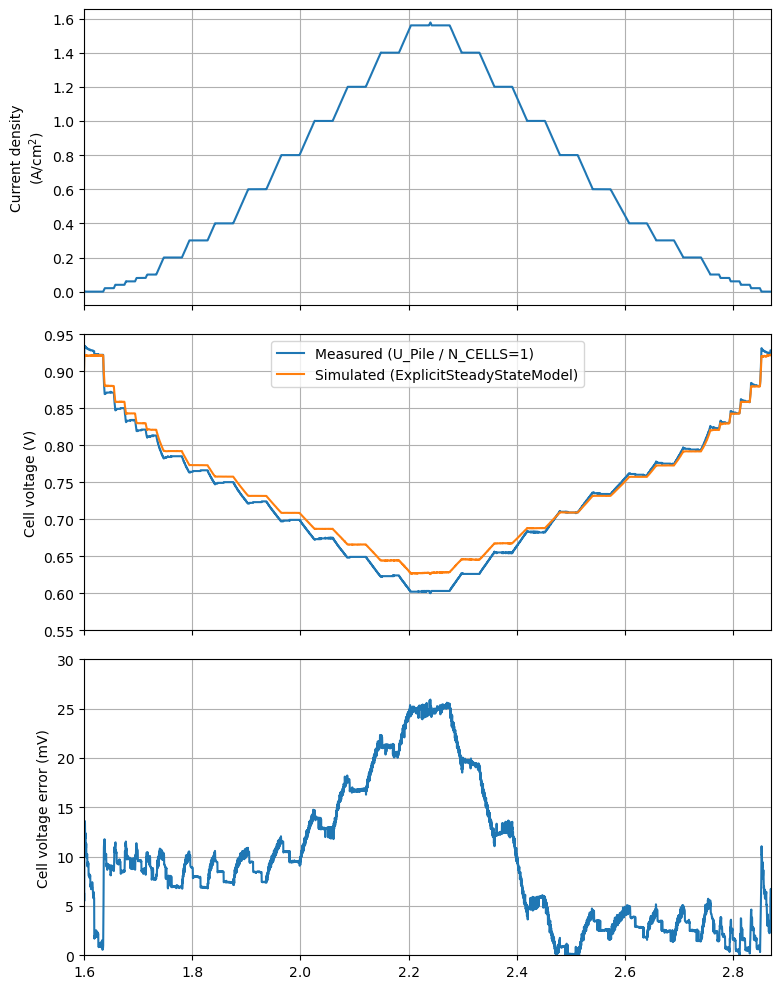

In [116]:
time_h = df['Time(h)'].to_numpy()
current_density = df['I_Pile(A)'].to_numpy() / CELL_AREA * 1e-4  # A/cm^2
measured_cell_voltage = df['U_Pile(V)'].to_numpy() / N_CELLS

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

axes[0].plot(time_h, current_density)
axes[0].set_ylabel('Current density\n(A/cm$^2$)')

axes[1].plot(time_h, measured_cell_voltage, label=f'Measured (U_Pile / N_CELLS={N_CELLS})')
axes[1].plot(time_h, cell_voltage, label='Simulated (ExplicitSteadyStateModel)')
axes[1].set_ylabel('Cell voltage (V)')
axes[1].set_ylim([0.55,0.95])
axes[1].legend()


axes[2].plot(time_h, np.abs(1e3*(measured_cell_voltage - cell_voltage)))
axes[2].set_ylabel('Cell voltage error (mV)')
axes[2].set_ylim([0,30])
axes[2].set_xlim([1.6,2.87])

for ax in axes:
    ax.grid()

fig.tight_layout()
plt.show()